In [1]:
!pip install lifelines

  Using cached lifelines-0.30.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached autograd-1.8.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached autograd_gamma-0.5.0-py3-none-any.whl
Using cached lifelines-0.30.3-py3-none-any.whl (409 kB)
Using cached autograd-1.8.0-py3-none-any.whl (51 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [lifelines]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import glob
import os
from tqdm import tqdm
import json
import requests
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# make tcga

In [ ]:
files = glob.glob("../TCGA/TCGA_PAAD/*/*.tsv")
dfs = []
for fn in tqdm(files, desc='Reading samples'):
    try:
        sample = fn.split("/")[-2]
        df = pd.read_table(fn, comment="#", usecols=["gene_id","gene_name", "tpm_unstranded"])
        df = df[~df["gene_id"].str.startswith("N_")]
        df = df.set_index("gene_id").rename(columns={"tpm_unstranded": sample})
        dfs.append(df)
    except Exception as e:
        print(f"Error processing file {fn}: {e}")
        raise

expr = pd.concat(dfs, axis=1)
expr.index = expr.index.str.replace(r"\.\d+$", "", regex=True)
expr.to_csv("TCGA_PAAD_TPM_unstranded.csv")

In [ ]:
# df_all = pd.read_csv('TCGA_PAAD_TPM_unstranded.csv')
# cols_remove = df_all.columns[df_all.columns.str.contains('gene_name')].tolist()
# cols_remove.remove('gene_name')
# df_all.drop(cols_remove, axis=1, inplace=True)
# df_all.to_csv("TCGA_PAAD_TPM_unstranded.csv")

In [ ]:
df_all = pd.read_csv('TCGA_PAAD_TPM_unstranded.csv')

In [ ]:
df_all.head()

In [ ]:
expr_log = np.log2(df_all.iloc[:, 3:] + 1.0, )

In [ ]:
expr_log

In [ ]:
expr_log['gene_name'] = df_all['gene_name']
expr_log.set_index('gene_name', inplace=True)


In [ ]:
expr_log.head()

In [ ]:
# 1) Collect all your file UUIDs from the download folders
folders = glob.glob("../TCGA/TCGA_PAAD/*")  # each named by file UUID
file_ids = [f.split("/")[-1] for f in folders]

# 2) Query the GDC API in batches to get the matching case_submitter_id
# chunk size of 100 to avoid URL‐length issues
mappings = []
for i in range(0, len(file_ids), 100):
    batch = file_ids[i:i+100]
    filters = {
        "op": "in",
        "content": {
            "field": "files.file_id",
            "value": batch
        }
    }
    params = {
        "filters": json.dumps(filters),
        "fields": "file_id,cases.case_id,cases.submitter_id",
        "format": "JSON",
        "size": len(batch)
    }
    r = requests.get("https://api.gdc.cancer.gov/files", params=params)
    r.raise_for_status()
    hits = r.json()["data"]["hits"]
    for h in hits:
        mappings.append({
            "file_id":       h["file_id"],
            "case_id":       h["cases"][0]["case_id"],
            "submitter_id":  h["cases"][0]["submitter_id"]
        })

map_df = pd.DataFrame(mappings)


In [ ]:
map_df

In [ ]:
map_df = map_df.sort_values(['submitter_id', 'file_id'])

# _rep1, _rep2, ... (first one can be left without suffix if you like)
rep = map_df.groupby('submitter_id').cumcount()
map_df['obs_id'] = np.where(rep == 0,
                            map_df['submitter_id'],
                            map_df['submitter_id'] + '_rep' + (rep+1).astype(str))

In [ ]:
map_df.sort_values(by='obs_id', ascending=False)

In [ ]:
id_map = dict(zip(map_df.file_id, map_df.submitter_id))
expr_log.rename(columns=id_map, inplace=True)

In [ ]:
expr_log_rep = np.log2(df_all.iloc[:, 3:] + 1.0)
expr_log_rep['gene_name'] = df_all['gene_name']
expr_log_rep.set_index('gene_name', inplace=True)
id_map = dict(zip(map_df.file_id, map_df.obs_id))
expr_log_rep.rename(columns=id_map, inplace=True)

In [ ]:
expr_log_rep.shape

In [ ]:
expr_log.head()

In [ ]:
files = glob.glob("../TCGA/Clinical_Data/*.tsv")
dfs = []    

In [ ]:
files = glob.glob("../TCGA/Clinical_Data/*.tsv")
metadata = {}
for fn in tqdm(files, desc='Reading samples'):
    try:
        sample = fn.split('/')[-1].split('.')[0]
        df = pd.read_table(fn)
        metadata[sample] = df
    except Exception as e:
        print(f"Error processing file {fn}: {e}")
        raise

In [ ]:
expr_df = expr_log.copy()
clin0    = metadata['clinical']       
followup = metadata['follow_up']      

In [ ]:
expr_df_ids = expr_df.columns[expr_df.columns.str.contains("T")].tolist()

In [ ]:
pd.set_option('display.max_column', 10)
pd.set_option('display.max_row', 10)

In [ ]:
interesting_cols = sorted(['cases.submitter_id', 'treatments.initial_disease_status', 'diagnoses.classification_of_tumor', 'treatments.treatment_or_therapy', 
                    'diagnoses.days_to_last_follow_up', 'diagnoses.tumor_grade_category', 'diagnoses.age_at_diagnosis', 'diagnoses.sites_of_involvement',
                    'diagnoses.tumor_grade', 'treatments.treatment_intent_type', 'diagnoses.days_to_diagnosis', 'diagnoses.uicc_clinical_stage', 'treatments.treatment_outcome',
                    'diagnoses.tumor_regression_grade', 'treatments.treatment_frequency', 'diagnoses.progression_or_recurrence','treatments.treatment_dose',
                    'diagnoses.metastasis_at_diagnosis', 'treatments.chemo_concurrent_to_radiation', 'treatments.drug_category', 'demographic.vital_status', 'demographic.race', 
                    'cases.days_to_lost_to_followup', 'cases.lost_to_followup', 'demographic.cause_of_death', 'demographic.days_to_death', 'demographic.gender', 'diagnoses.days_to_last_known_disease_status',
                    'diagnoses.days_to_best_overall_response', 'diagnoses.days_to_recurrence',])

In [ ]:
clin0 = clin0[interesting_cols]

In [ ]:
clin0.reset_index(drop=True, inplace=True)

In [ ]:
clin0.head()

In [ ]:
import numpy as np

In [ ]:
def summarize(group):
    time_death = group['demographic.days_to_death'].dropna()
    time_follow = group['diagnoses.days_to_last_follow_up'].dropna()
    if len(time_death):
        time = time_death.max()
    else:
        time = time_follow.max() if len(time_follow) else np.nan

    # event: 1 if any row says 'Dead'
    event = int((group['demographic.vital_status'] == 'Dead').any())

    return pd.Series({'time': time, 'event': event})
clin0 = clin0.replace("'--", np.nan)
clin_df = clin0.groupby('cases.submitter_id').apply(summarize).dropna(subset=['time'])

In [ ]:
clin_tab = clin_df.reset_index().rename(columns={'cases.submitter_id':'submitter_id'})

In [ ]:
clin_tab

In [ ]:
clin_tab = clin_tab[clin_tab.submitter_id.isin(expr_df_ids)]

In [ ]:
clin_tab['gender'] = clin_tab.submitter_id.map(dict(zip(clin0['cases.submitter_id'], clin0['demographic.gender'])))
clin_tab['gender_encoded'] = clin_tab['gender'].map({'female': 1, 'male':0})

In [ ]:
clin_tab #.shape

In [ ]:
expr_log_t = expr_log.T.reset_index()

In [ ]:
expr_log_t.rename(columns={'index': 'submitter_id'}, inplace=True)

In [ ]:
expr_log_t.head()

In [ ]:
clin_tab.shape

In [ ]:
expr_log_t.shape

In [ ]:
df_tcga = pd.merge(clin_tab, expr_log_t, on='submitter_id')

In [ ]:
df_tcga.shape

In [ ]:
df_tcga['time'] = df_tcga['time'].astype(str).str.replace("'", "")
df_tcga['time'] = pd.to_numeric(df_tcga['time'], errors='coerce')
df_tcga['time'] = df_tcga['time'].astype(int)

In [ ]:
df_tcga

In [ ]:
df_tcga.to_csv('df_tcga.csv')

In [ ]:
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 10)

In [ ]:
expr_df_filtered = expr_df.loc[:,~expr_df.columns.duplicated()].copy()

In [ ]:
expr_df_filtered.shape

# Save

In [ ]:
df.to_csv('radio_dge_tcga.csv')

# Reload

In [6]:
pwd

'/'

In [4]:
df_tcga = pd.read_csv('workspace/hpca/hpca_downstream/df_tcga.csv')

In [5]:
df_tcga

,Unnamed: 0,submitter_id,time,event,gender,gender_encoded,TSPAN6,TNMD,DPM1,SCYL3,...,AL451106.1,AC092910.4,AC073611.1,AC136977.1,AC078856.1,AC008763.4,AL592295.6,AC006486.3,AL391628.1,AP006621.6
0,0,TCGA-2J-AAB1,66,1,male,0,4.388644,0.000000,5.883112,3.045128,...,0.0,0.0,0.198494,0.0,0.000000,0.000000,2.974438,0.0,0.111165,1.392702
1,1,TCGA-2J-AAB4,729,0,male,0,4.917403,0.000000,6.133742,2.954103,...,0.0,0.0,0.283211,0.0,1.047329,0.000000,3.236615,0.0,0.047957,0.795684
2,2,TCGA-2J-AAB6,293,1,male,0,4.479179,0.000000,7.164674,2.350469,...,0.0,0.0,0.275126,0.0,0.000000,0.000000,3.438745,0.0,0.000000,1.048864
3,3,TCGA-2J-AAB8,80,0,male,0,4.603798,0.609093,6.580254,3.776809,...,0.0,0.0,0.626860,0.0,0.000000,0.000000,4.076910,0.0,0.068189,1.412240
4,4,TCGA-2J-AAB9,627,1,female,1,5.008845,0.000000,6.337492,2.812046,...,0.0,0.0,0.427821,0.0,0.000000,0.000000,3.159016,0.0,0.020911,1.118360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,178,TCGA-YB-A89D,350,0,male,0,4.694958,0.151859,6.519344,2.558513,...,0.0,0.0,0.264476,0.0,0.000000,0.000000,2.831756,0.0,0.071900,0.945907
179,179,TCGA-YB-A89D,350,0,male,0,4.632838,4.018269,6.128809,2.146590,...,0.0,0.0,0.293959,0.0,0.000000,0.000000,2.326135,0.0,0.059771,0.718701
180,180,TCGA-YH-A8SY,388,0,female,1,4.498410,0.000000,6.347317,2.455518,...,0.0,0.0,0.461843,0.0,0.000000,0.027579,2.578287,0.0,0.034075,0.630871
181,181,TCGA-YY-A8LH,2016,0,female,1,4.881718,0.000000,6.466725,3.112300,...,0.0,0.0,0.401630,0.0,0.000000,0.000000,3.773131,0.0,0.154065,1.034497


In [6]:
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 10)

In [7]:
df_tcga_filtered = df_tcga.loc[:,~df_tcga.columns.duplicated()].copy()

In [8]:
df_tcga_filtered.shape

(183, 60666)

In [9]:
df_tcga_filtered

,Unnamed: 0,submitter_id,time,event,gender,...,AC008763.4,AL592295.6,AC006486.3,AL391628.1,AP006621.6
0,0,TCGA-2J-AAB1,66,1,male,...,0.000000,2.974438,0.0,0.111165,1.392702
1,1,TCGA-2J-AAB4,729,0,male,...,0.000000,3.236615,0.0,0.047957,0.795684
2,2,TCGA-2J-AAB6,293,1,male,...,0.000000,3.438745,0.0,0.000000,1.048864
3,3,TCGA-2J-AAB8,80,0,male,...,0.000000,4.076910,0.0,0.068189,1.412240
4,4,TCGA-2J-AAB9,627,1,female,...,0.000000,3.159016,0.0,0.020911,1.118360
...,...,...,...,...,...,...,...,...,...,...,...
178,178,TCGA-YB-A89D,350,0,male,...,0.000000,2.831756,0.0,0.071900,0.945907
179,179,TCGA-YB-A89D,350,0,male,...,0.000000,2.326135,0.0,0.059771,0.718701
180,180,TCGA-YH-A8SY,388,0,female,...,0.027579,2.578287,0.0,0.034075,0.630871
181,181,TCGA-YY-A8LH,2016,0,female,...,0.000000,3.773131,0.0,0.154065,1.034497


In [10]:
novel_padc_markers = [
    "ADAM28",    # Correlation: pdac_up; pdac_specific_up
    "STYK1",     # Correlation: pdac_specific_up
    "EFNA5",     # Correlation: pdac_up
    "HRH1",      # Correlation: pdac_up
    "ONECUT3",   # Correlation: pdac_specific_up
]

regen_remodeling_program = [
    # acinar maturity / differentiated epithelial identity, all recovered as pdac_down or pdac_specific_down
    "AQP8",       # Correlation: pdac_down
    "AMY2A",      # Correlation: pdac_down; pdac_specific_down
    "CPA1",       # Correlation: pdac_down
    "CPA2",       # Correlation: regen_down; pdac_down; shared_down
    "CTRB1",      # Correlation: pdac_down; pdac_specific_down
    "PRSS1",      # Correlation: pdac_down
    "GP2",        # Correlation: pdac_down
    "CLPS",       # Correlation: pdac_down; pdac_specific_down; PyDESeq2: Regen_vs_PDAC

    # repair / regenerative-metaplastic overlay
    "AGR2",       # Correlation: regen_up
    "AQP5",       # Correlation: regen_up
    "WFDC2",      # Correlation: regen_up; regen_specific_up
    "IFITM1",     # Correlation: regen_specific_up
    "PIGR",       # Correlation: regen_specific_up
    "KLF2",       # Correlation: regen_specific_up
    "EREG",       # Correlation: regen_up
]

malignant_remodeling_program = [
    #canonical
    "S100P",
    "TMPRSS4",
    "MSLN",
    "PSCA", 
    "GPRC5A",
    #emerging
    "SEMA3C",
    "LAMB3",
    "LAMC2",
    "PCDH7",
    #novel
    "ADAM28",
    "STYK1",
    "EFNA5",
    "HRH1",
    "ONECUT3",
    #branch-defining
    "FHL2",
    "ANXA1",
    "KRT19",
    "SULF2",
]

In [11]:
df_tcga_filtered.columns

Index(['Unnamed: 0', 'submitter_id', 'time', 'event', 'gender',
       'gender_encoded', 'TSPAN6', 'TNMD', 'DPM1', 'SCYL3',
       ...
       'AL451106.1', 'AC092910.4', 'AC073611.1', 'AC136977.1', 'AC078856.1',
       'AC008763.4', 'AL592295.6', 'AC006486.3', 'AL391628.1', 'AP006621.6'],
      dtype='object', length=60666)

In [12]:

df = df_tcga_filtered.copy()
df['time'] = pd.to_numeric(df['time'], errors='coerce').astype(int)
df['event'] = pd.to_numeric(df['event'], errors='coerce').astype(int)
gene_cols = [gene for gene in novel_padc_markers if gene in df.columns]
print(f'Number of genes: {len(gene_cols)}')
from sklearn.feature_selection import VarianceThreshold
vt = VarianceThreshold(threshold=1e-6)
if gene_cols:
    vt.fit(df[gene_cols])
    mask = vt.get_support()
    kept_genes = [g for g, keep in zip(gene_cols, mask) if keep]
else:
    kept_genes = []

print(f"Dropped {len(gene_cols) - len(kept_genes)} zero‐variance genes.")

# Prepare Cox model input
cox_cols = kept_genes + ['gender_encoded', 'time', 'event']
df_cox = df[cox_cols].copy()
df_cox.index = df['submitter_id']

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

display(df_cox.head())

from lifelines import CoxPHFitter

if len(kept_genes) > 0:
    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(
        df_cox,
        duration_col='time',
        event_col='event'
    )
    display(cph.summary.sort_values('p'))
else:
    print("No marker genes to model with sufficient variance.")

Number of genes: 5
Dropped 0 zero‐variance genes.


,ADAM28,STYK1,EFNA5,HRH1,ONECUT3,gender_encoded,time,event
submitter_id,,,,,,,,
TCGA-2J-AAB1,5.823484,3.276884,3.829190,3.641685,4.722444,0,66,1
TCGA-2J-AAB4,4.927214,4.244118,4.183463,3.919350,4.665518,0,729,0
TCGA-2J-AAB6,1.779050,3.717649,3.272486,3.583302,4.577447,0,293,1
TCGA-2J-AAB8,3.931900,3.846834,4.347205,3.601934,5.791507,0,80,0
TCGA-2J-AAB9,3.431302,2.551196,3.562120,3.465517,2.641916,1,627,1


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
HRH1,0.248802,1.282488,0.131837,-0.009595,0.507198,0.990451,1.660632,0.0,1.887184,0.059136,4.079831
ADAM28,0.126620,1.134986,0.085570,-0.041095,0.294335,0.959738,1.342233,0.0,1.479719,0.138948,2.847380
ONECUT3,-0.056597,0.944975,0.060677,-0.175523,0.062329,0.839018,1.064312,0.0,-0.932751,0.350949,1.510668
STYK1,0.100241,1.105438,0.107575,-0.110602,0.311084,0.895295,1.364904,0.0,0.931828,0.351425,1.508709
gender_encoded,0.136050,1.145739,0.190405,-0.237137,0.509237,0.788883,1.664020,0.0,0.714528,0.474901,1.074303
EFNA5,0.051666,1.053024,0.119021,-0.181611,0.284942,0.833926,1.329686,0.0,0.434091,0.664223,0.590261


In [13]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

def km_plot_gene(df, gene, cut="median", ax=None):
    """Plot KM curves for gene using a binary split."""
    x = df[gene]
    if cut == "median":
        thresh = x.median()
        group = np.where(x > thresh, "High", "Low")
    else:
        # numeric threshold if you want to pass e.g., cut=2.3
        thresh = float(cut)
        group = np.where(x > thresh, "High", "Low")

    tmp = df.assign(group=group)

    kmf = KaplanMeierFitter()
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4), dpi=120)

    for label in ["High", "Low"]:
        sel = tmp["group"] == label
        kmf.fit(durations=tmp.loc[sel, "time"],
                event_observed=tmp.loc[sel, "event"],
                label=f"{label} {gene} (n={sel.sum()})")
        kmf.plot(ax=ax, ci_show=True)

    # log-rank test
    hi = tmp["group"] == "High"
    lo = tmp["group"] == "Low"
    res = logrank_test(tmp.loc[hi, "time"], tmp.loc[lo, "time"],
                       event_observed_A=tmp.loc[hi, "event"],
                       event_observed_B=tmp.loc[lo, "event"])
    p = res.p_value

    ax.set_title(f"{gene}: High vs Low (cut={thresh:.3g})")
    ax.set_xlabel("Time")
    ax.set_ylabel("Survival probability")
    ax.legend(frameon=False)
    ax.text(0.02, 0.02, f"log-rank p = {p:.3g}", transform=ax.transAxes)

    return ax, p, tmp

In [15]:
gene_cols

['ADAM28', 'STYK1', 'EFNA5', 'HRH1', 'ONECUT3']

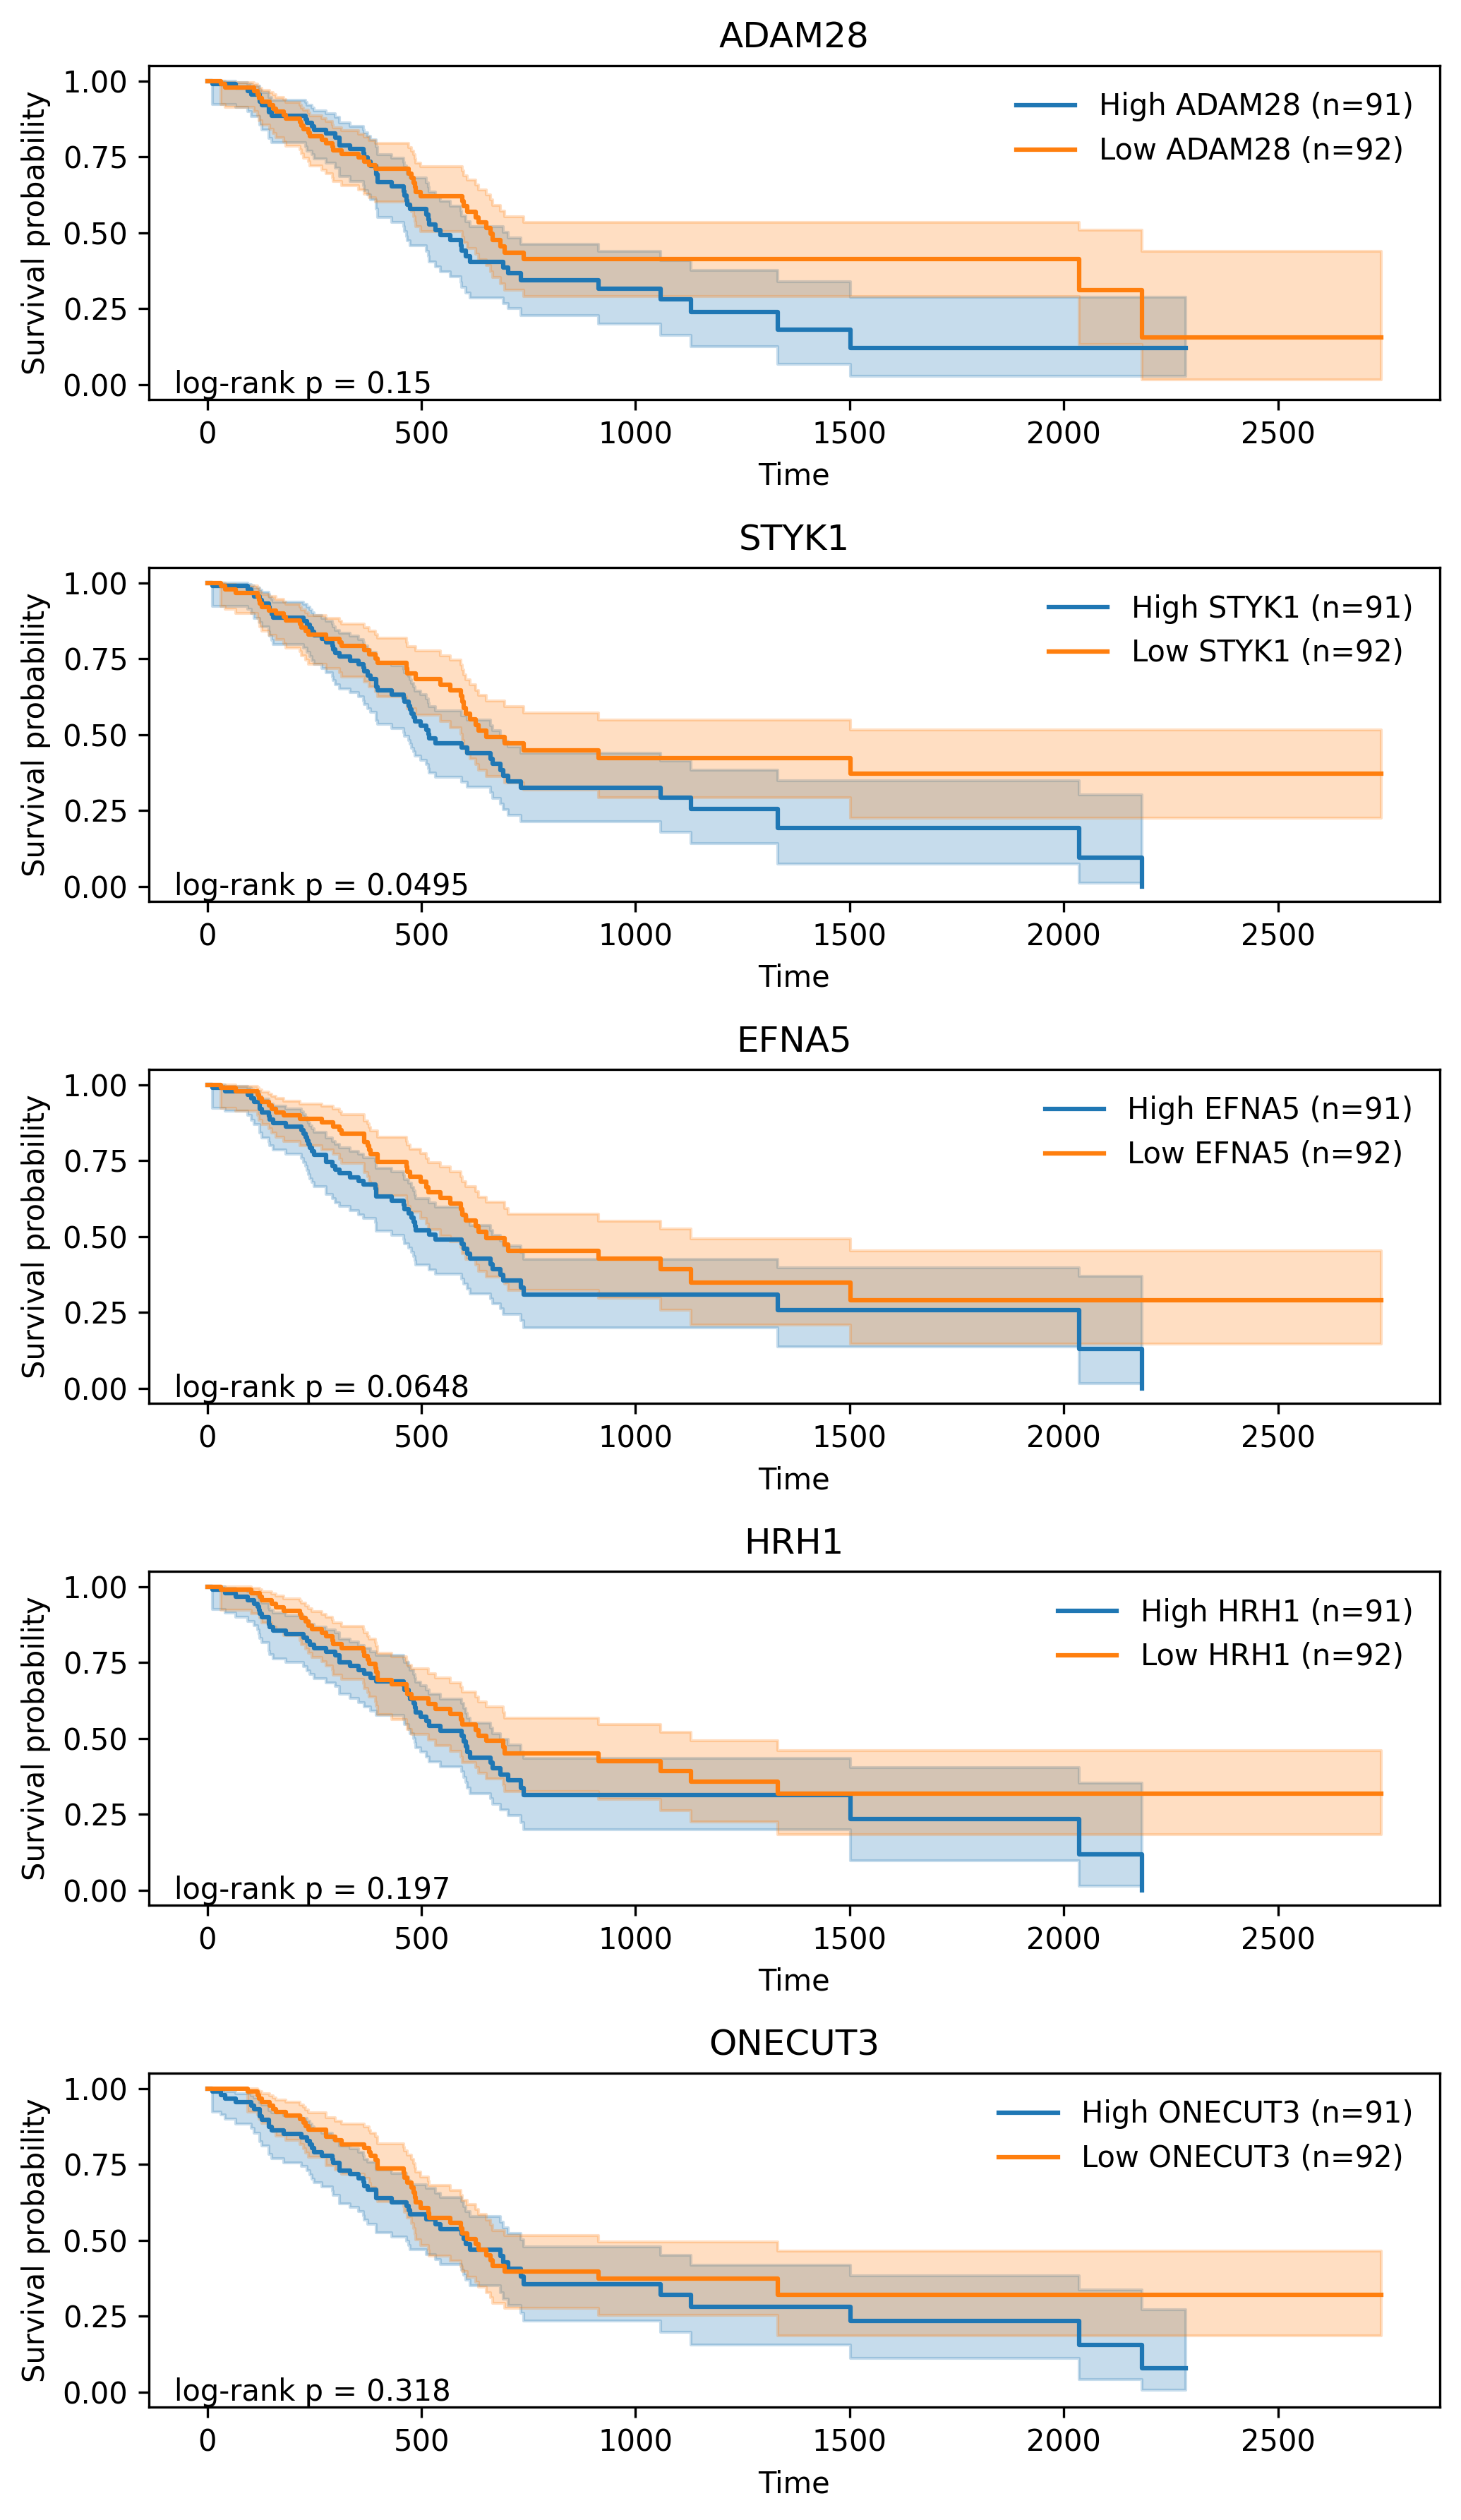

In [19]:
fig, axs = plt.subplots(5, 1, figsize=(7, 12), dpi=300, sharey=True)
axs = axs.flatten()
for i, gene in enumerate(gene_cols):
    ax, p, tmp = km_plot_gene(df, gene, ax=axs[i])  # pass the i-th Axes
    ax.set_title(f"{gene}")

fig.tight_layout()
# plt.savefig('TCGA_Radiotherapy/top_four.png', dpi=300)

In [20]:
import os
os.chdir('workspace/hpca/hpca_downstream/PDAC_Results/')

Malignant genes used: ['S100P', 'TMPRSS4', 'MSLN', 'PSCA', 'GPRC5A', 'SEMA3C', 'LAMB3', 'LAMC2', 'PCDH7', 'ADAM28', 'STYK1', 'EFNA5', 'HRH1', 'ONECUT3', 'FHL2', 'ANXA1', 'KRT19', 'SULF2']
Regenerative genes used: ['AQP8', 'AMY2A', 'CPA1', 'CPA2', 'CTRB1', 'PRSS1', 'GP2', 'CLPS', 'AGR2', 'AQP5', 'WFDC2', 'IFITM1', 'PIGR', 'KLF2', 'EREG']

Cox model summary:


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
malignant_score,0.376885,1.457737,0.211720,-0.038079,0.791849,0.962637,2.207475,0.0,1.780109,0.075058,3.735848
regenerative_score,0.317830,1.374143,0.235842,-0.144412,0.780072,0.865531,2.181630,0.0,1.347640,0.177774,2.491882
gender_encoded,0.182213,1.199870,0.189560,-0.189318,0.553744,0.827524,1.739754,0.0,0.961242,0.336431,1.571619
axis_score,0.170062,1.185378,0.203776,-0.229333,0.569456,0.795064,1.767305,0.0,0.834550,0.403971,1.307677



Concordance index:
0.5


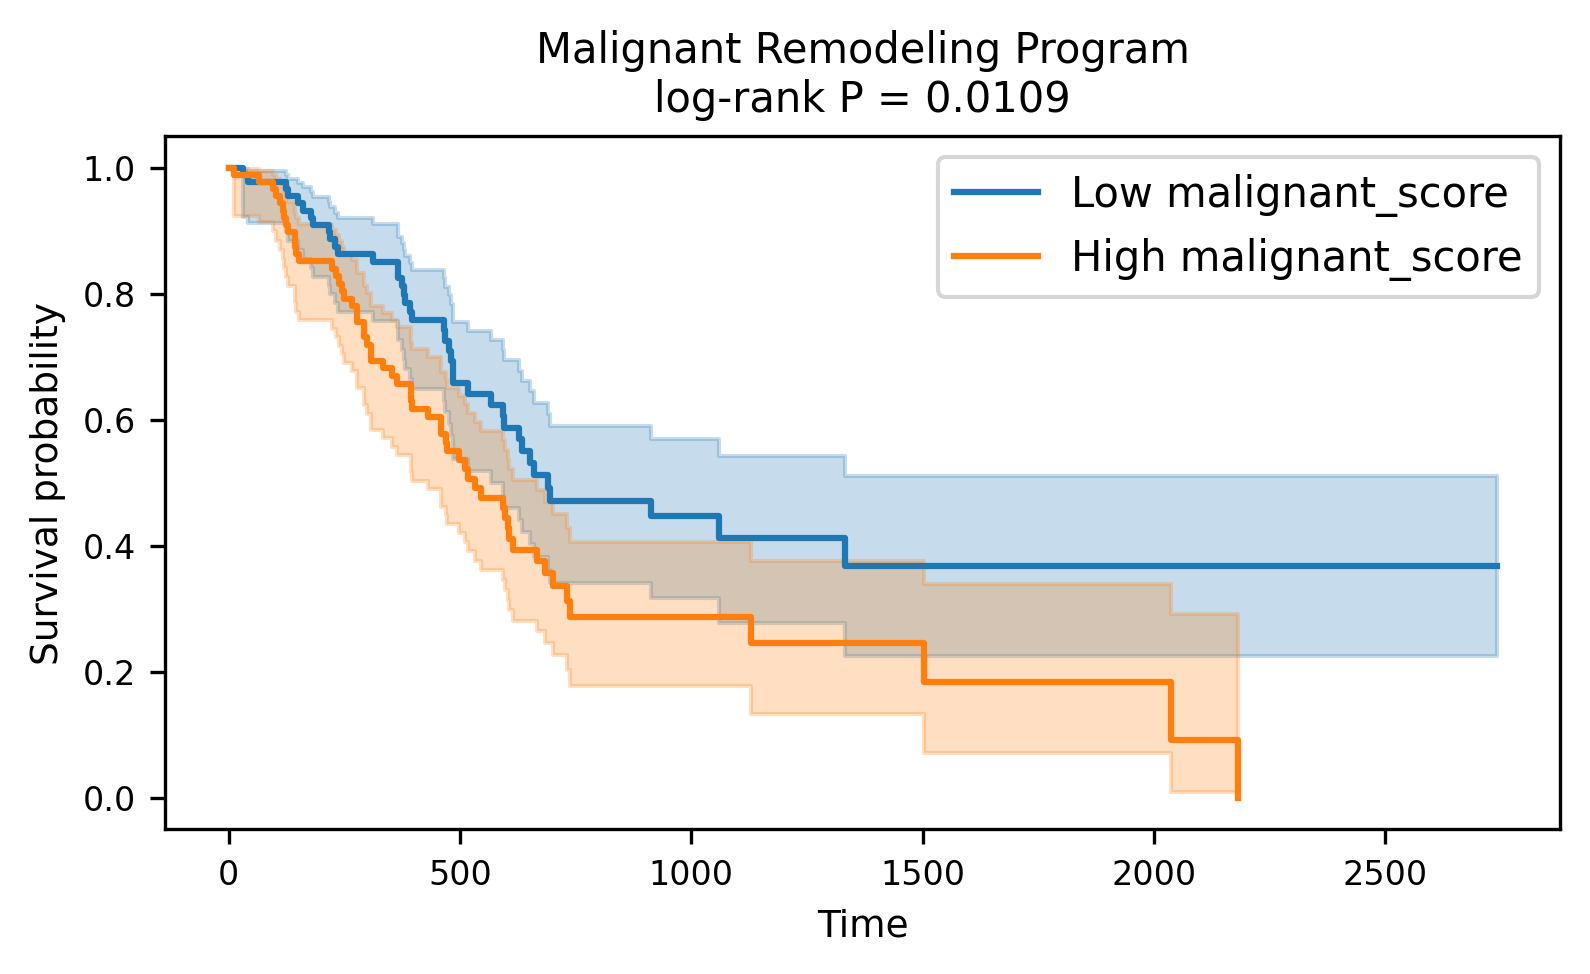

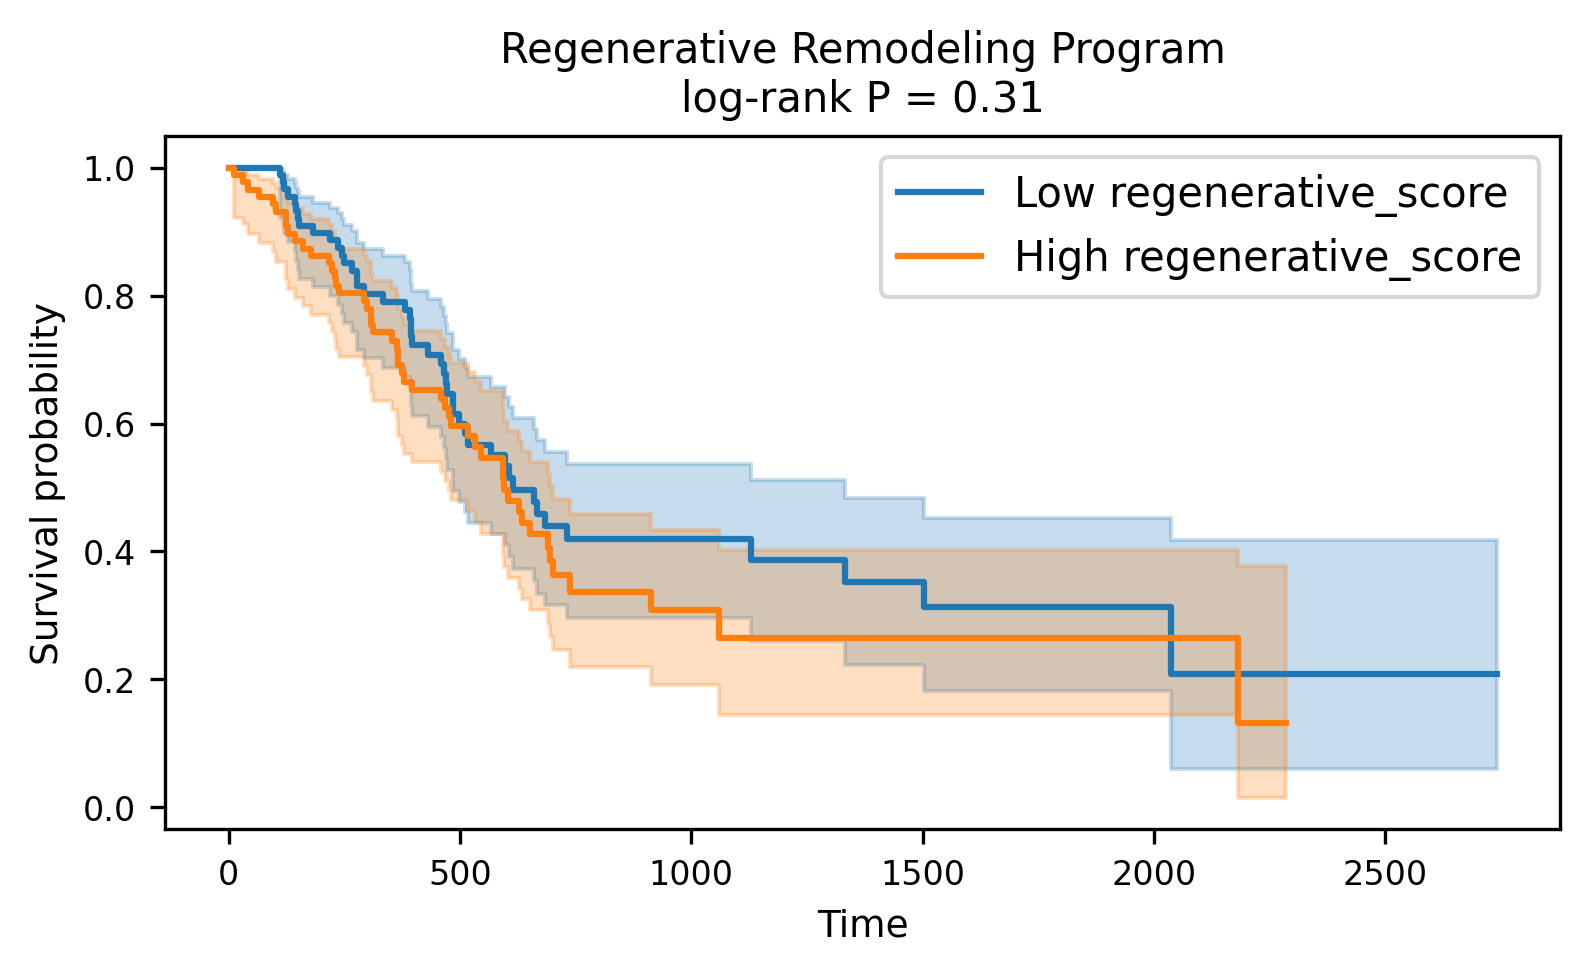

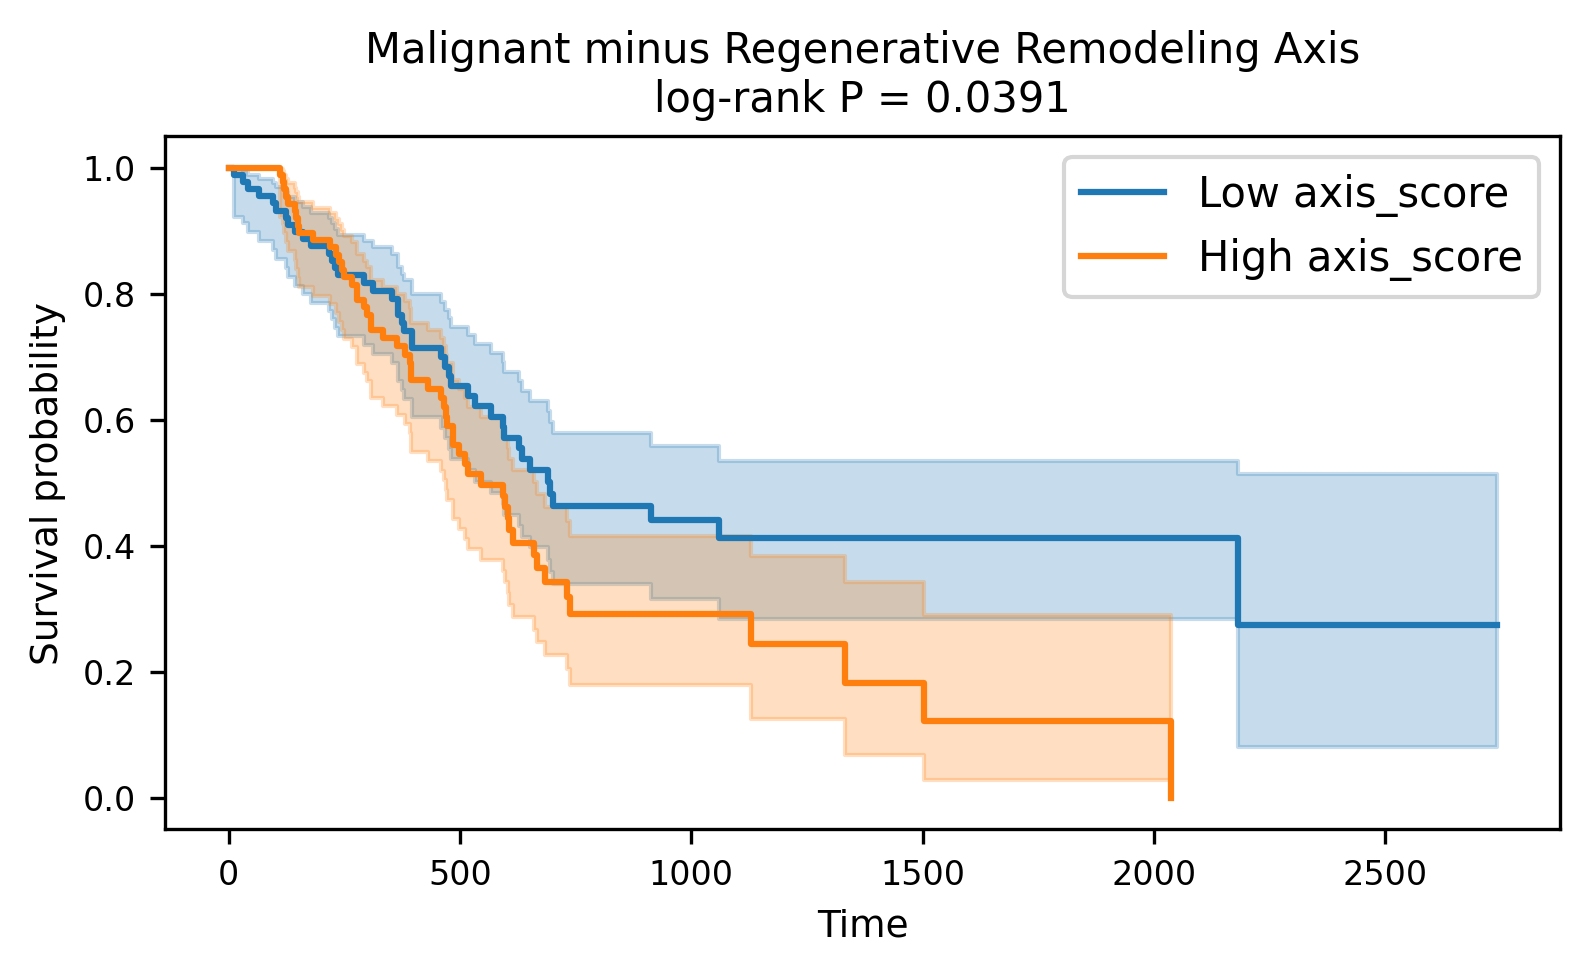


Log-rank P values:
Malignant score: 0.010891663534620026
Regenerative score: 0.31036765178046155
Axis score: 0.03914683087286629


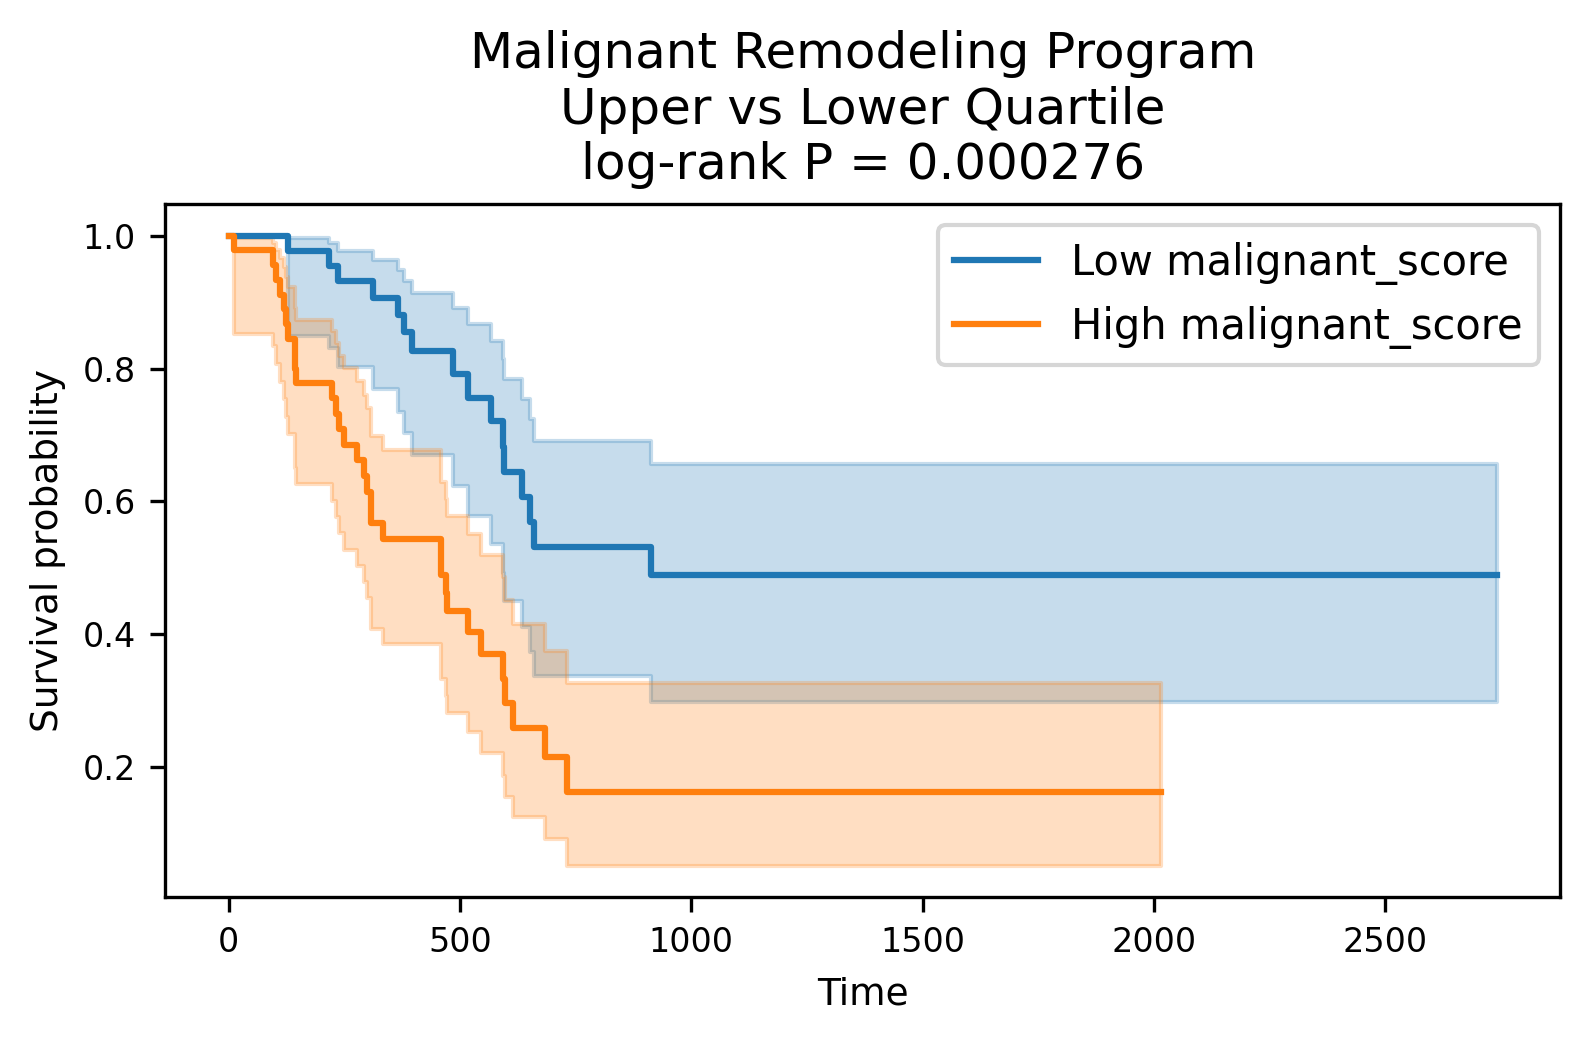

malignant_score log-rank P: 0.0002758495165825026


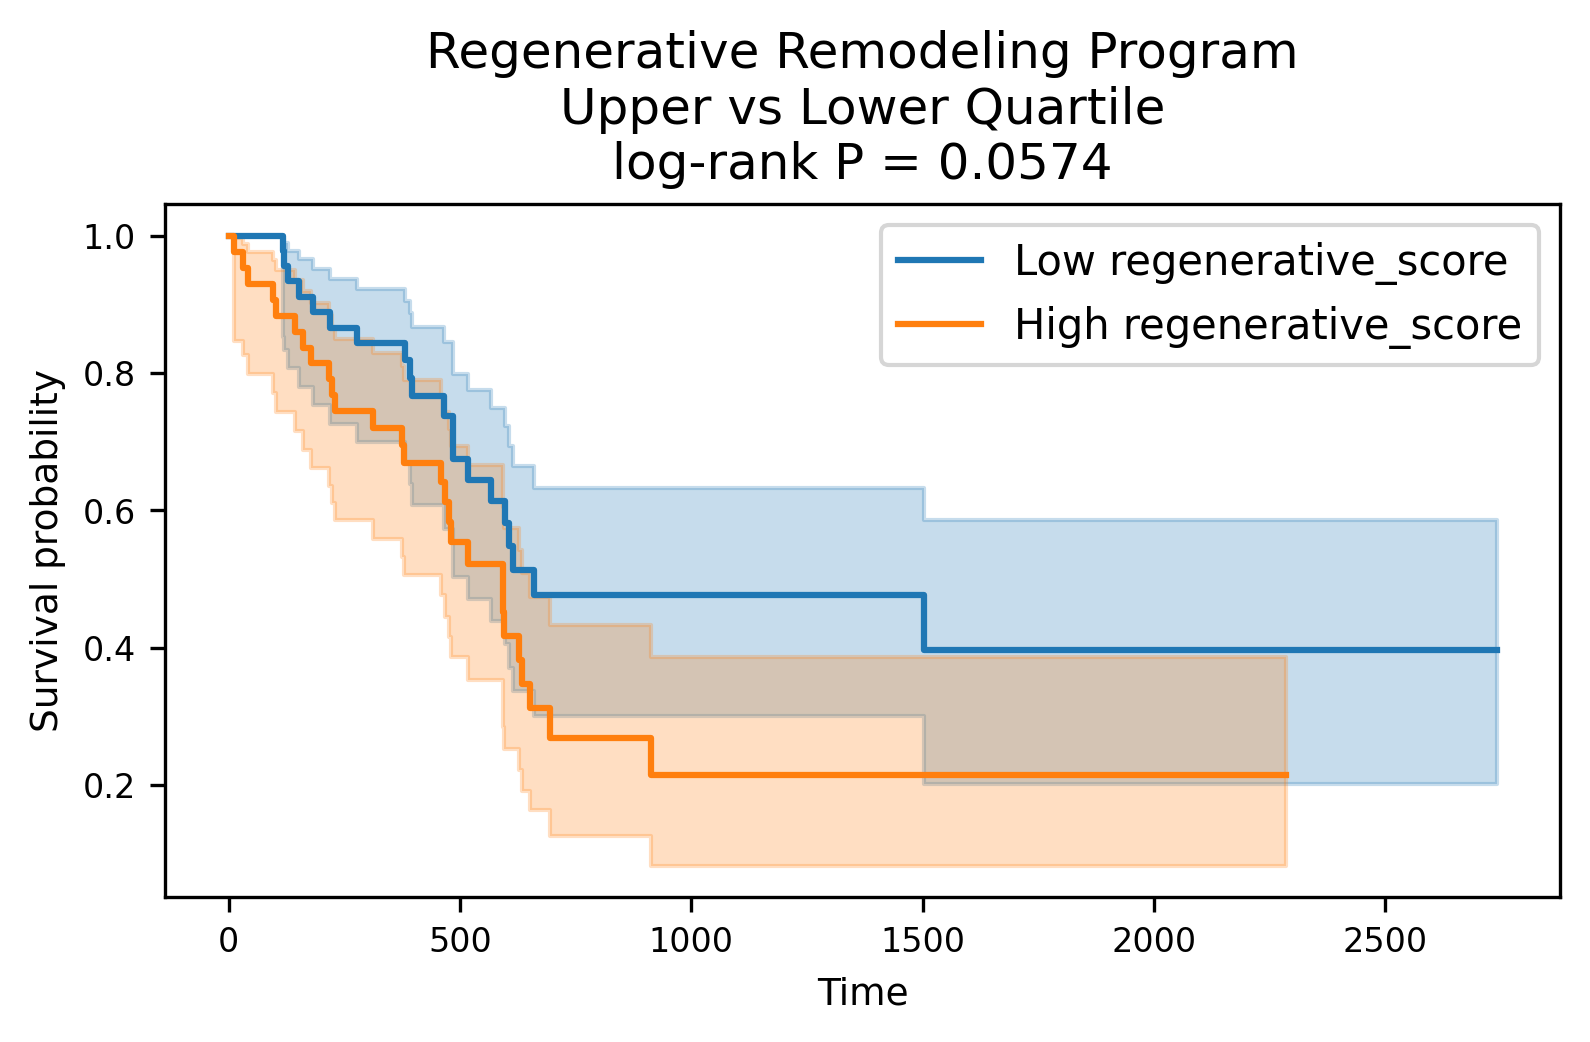

regenerative_score log-rank P: 0.05735720563953046


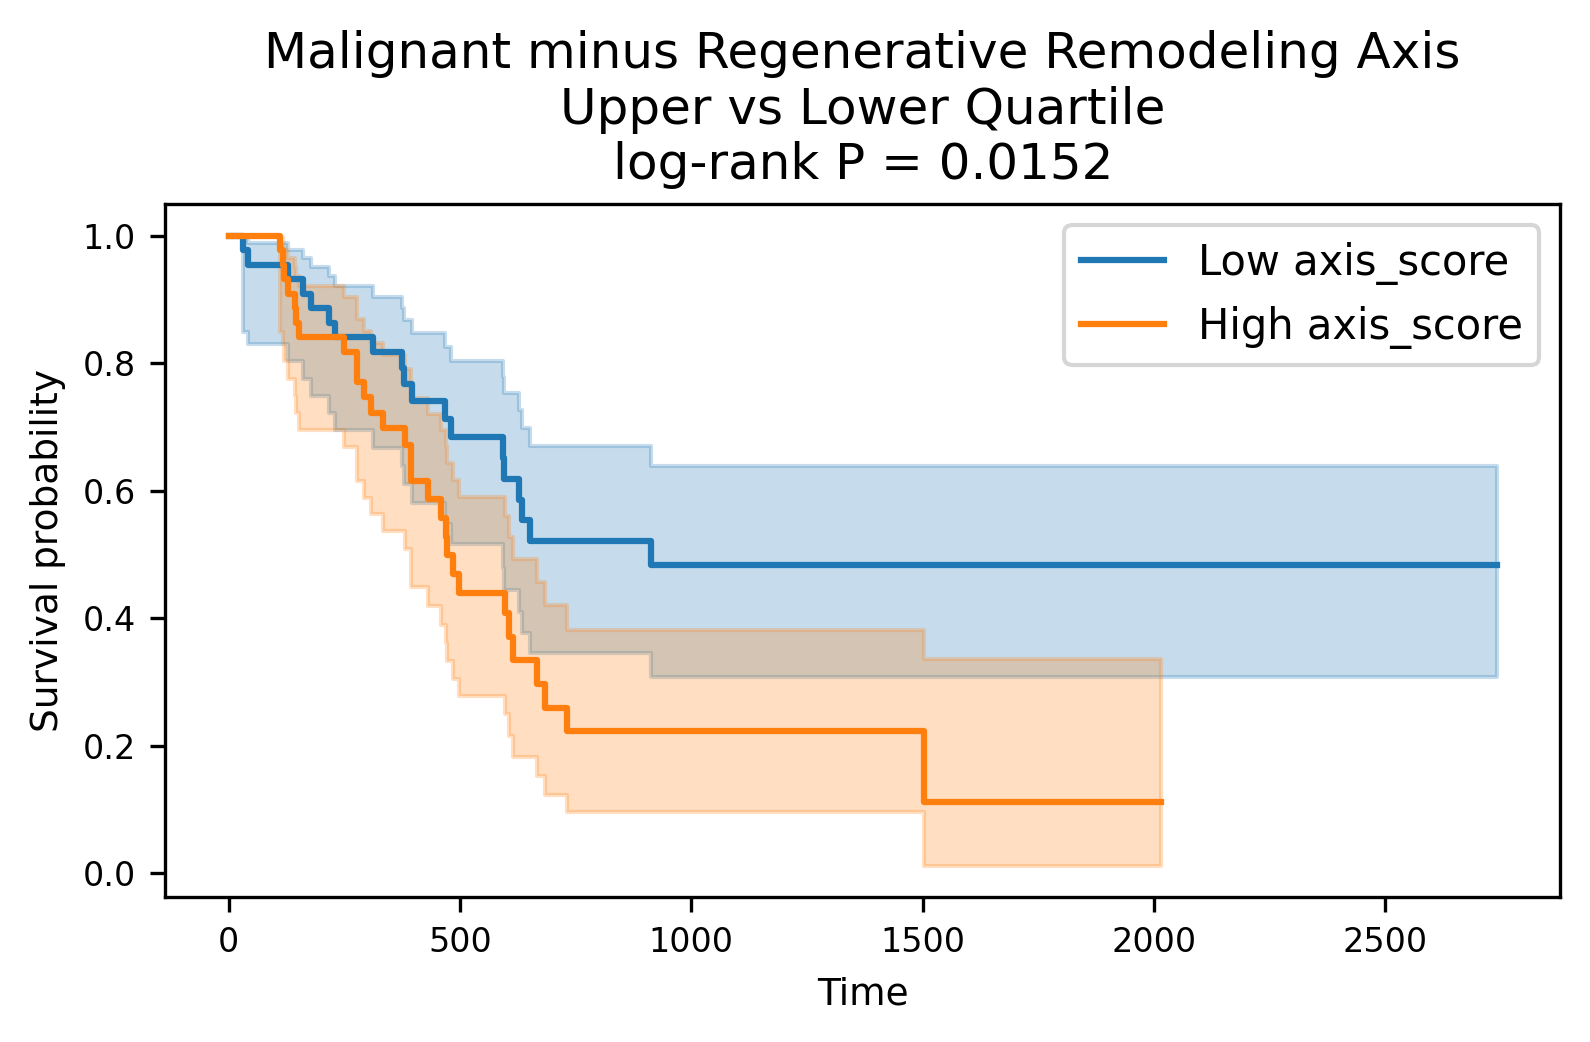

axis_score log-rank P: 0.015241186583119556


np.float64(0.015241186583119556)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import zscore
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test

df = df_tcga_filtered.copy()

df["time"] = pd.to_numeric(df["time"], errors="coerce")
df["event"] = pd.to_numeric(df["event"], errors="coerce")

df = df.dropna(subset=["time", "event"]).copy()
df["event"] = df["event"].astype(int)

if "submitter_id" in df.columns:
    df.index = df["submitter_id"]


malignant_genes = [g for g in malignant_remodeling_program if g in df.columns]
regenerative_genes = [g for g in regen_remodeling_program if g in df.columns]

print("Malignant genes used:", malignant_genes)
print("Regenerative genes used:", regenerative_genes)

# -----------------------------
# 3. Z-score genes and compute scores
# -----------------------------
for g in malignant_genes + regenerative_genes:
    df[g + "_z"] = zscore(df[g].astype(float), nan_policy="omit")

df["malignant_score"] = df[[g + "_z" for g in malignant_genes]].mean(axis=1)
df["regenerative_score"] = df[[g + "_z" for g in regenerative_genes]].mean(axis=1)

# Malignant-vs-regenerative axis
df["axis_score"] = df["malignant_score"] - df["regenerative_score"]

# -----------------------------
# 4. Cox model
# -----------------------------
cox_cols = ["malignant_score", "regenerative_score", "axis_score", "time", "event"]

if "gender_encoded" in df.columns:
    cox_cols.insert(3, "gender_encoded")

cox_df = df[cox_cols].dropna().copy()

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df, duration_col="time", event_col="event")

print("\nCox model summary:")
display(cph.summary.sort_values("p"))

print("\nConcordance index:")
print(cph.concordance_index_)

# -----------------------------
# 5. Kaplan-Meier function
# -----------------------------
def plot_km_for_score(df, score_col, title):
    tmp = df[["time", "event", score_col]].dropna().copy()
    tmp["group"] = np.where(
        tmp[score_col] > tmp[score_col].median(),
        "High",
        "Low"
    )

    high = tmp["group"] == "High"
    low = tmp["group"] == "Low"

    lr = logrank_test(
        tmp.loc[high, "time"],
        tmp.loc[low, "time"],
        event_observed_A=tmp.loc[high, "event"],
        event_observed_B=tmp.loc[low, "event"]
    )

    kmf = KaplanMeierFitter()

    fig, ax = plt.subplots(figsize=(6, 3), dpi=300)

    for group in ["Low", "High"]:
        mask = tmp["group"] == group
        kmf.fit(
            durations=tmp.loc[mask, "time"],
            event_observed=tmp.loc[mask, "event"],
            label=f"{group} {score_col}"
        )
        kmf.plot_survival_function(ax=ax)

    ax.set_title(f"{title}\nlog-rank P = {lr.p_value:.3g}", fontsize=10)
    ax.set_xlabel("Time", fontsize=9)
    ax.set_ylabel("Survival probability", fontsize=9)
    ax.tick_params(axis='both', labelsize=8)
    # Save the Kaplan-Meier plot to file as PNG and PDF
    fig.savefig(f"km_{score_col}.svg", bbox_inches='tight', dpi=300)
    fig.savefig(f"km_{score_col}.svg", bbox_inches='tight')
    plt.show()


    return lr.p_value

# -----------------------------
# 6. KM plots
# -----------------------------
p_malignant = plot_km_for_score(
    df,
    "malignant_score",
    "Malignant Remodeling Program"
)

p_regenerative = plot_km_for_score(
    df,
    "regenerative_score",
    "Regenerative Remodeling Program"
)

p_axis = plot_km_for_score(
    df,
    "axis_score",
    "Malignant minus Regenerative Remodeling Axis"
)

print("\nLog-rank P values:")
print("Malignant score:", p_malignant)
print("Regenerative score:", p_regenerative)
print("Axis score:", p_axis)


def plot_km_quantiles(df, score_col, title):
    tmp = df[["time", "event", score_col]].dropna().copy()
    # Define quartiles
    q25 = tmp[score_col].quantile(0.25)
    q75 = tmp[score_col].quantile(0.75)
    # Keep only bottom and top quartiles
    tmp = tmp[
        (tmp[score_col] <= q25) |
        (tmp[score_col] >= q75)
    ].copy()
    tmp["group"] = np.where(
        tmp[score_col] >= q75,
        "High",
        "Low"
    )
    high = tmp["group"] == "High"
    low = tmp["group"] == "Low"
    # Log-rank test

    lr = logrank_test(
        tmp.loc[high, "time"],
        tmp.loc[low, "time"],
        event_observed_A=tmp.loc[high, "event"],
        event_observed_B=tmp.loc[low, "event"]
    )

    # KM plot

    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=(6,3), dpi=300)
    for group in ["Low", "High"]:
        mask = tmp["group"] == group
        kmf.fit(

            durations=tmp.loc[mask, "time"],
            event_observed=tmp.loc[mask, "event"],
            label=f"{group} {score_col}"
        )
        kmf.plot_survival_function(ax=ax)
    ax.set_title(

        f"{title}\nUpper vs Lower Quartile\nlog-rank P = {lr.p_value:.3g}"

    )
    ax.set_xlabel("Time", fontsize=9)
    ax.set_ylabel("Survival probability", fontsize=9)
    ax.tick_params(axis='both', labelsize=8)
    fig.savefig(f"{score_col}_km_plot.svg", bbox_inches="tight", dpi=300)
    plt.show()
    print(f"{score_col} log-rank P:", lr.p_value)
    return lr.p_value

plot_km_quantiles(
    df,
    "malignant_score",
    "Malignant Remodeling Program"
)

plot_km_quantiles(
    df,
    "regenerative_score",
    "Regenerative Remodeling Program"
)

plot_km_quantiles(
    df,
    "axis_score",
    "Malignant minus Regenerative Remodeling Axis"
)

In [44]:
df.shape

(183, 60688)

In [43]:
upper_quartile_n = (df["malignant_score"] >= df["malignant_score"].quantile(0.75)).sum()
lower_quartile_n = (df["malignant_score"] <= df["malignant_score"].quantile(0.25)).sum()

print("upper quartile n:", upper_quartile_n)
print("lower quartile n:", lower_quartile_n)

upper quartile n: 46
lower quartile n: 46
